# Piloto TwitterAPI.io - $GME enero 2021

**Objetivo (Plan de Ingestion X v2, secciones 3.4 y 12):** validar con costo minimo, antes de comprometer presupuesto:

1. Que la API key funciona y la conexion es estable.
2. **Profundidad historica**: que la busqueda regresa tweets de enero 2021 (no solo recientes). Esta es la validacion critica.
3. Que el filtro de cashtag ($GME) y la ventana temporal funcionan.
4. El volumen real por ventana de evento, para extrapolar el costo de la Fase 1.

**Control de costo:** tarifa base USD 0.15 por 1,000 tweets. El tope `MAX_TWEETS` de este notebook (500 por default) cuesta ~USD 0.075 y cabe en el credito gratis de USD 0.10.

**Prerequisito:** `cp .env.example .env` y pegar la API key del Dashboard de twitterapi.io.

In [9]:
import os
import sys
from datetime import datetime
from pathlib import Path

import pandas as pd
from dotenv import load_dotenv

# Localiza la raiz del modulo Code/x sin importar desde donde se abrio Jupyter
_candidates = [Path.cwd(), Path.cwd().parent,
               Path.home() / "Claude" / "Master Thesis" / "Code" / "x"]
try:
    MODULE_ROOT = next(p for p in _candidates if (p / "scripts" / "x_client.py").exists())
except StopIteration:
    raise FileNotFoundError(
        "No encuentro scripts/x_client.py. Ajusta MODULE_ROOT a la ruta real de Code/x."
    )
print("MODULE_ROOT:", MODULE_ROOT)

sys.path.insert(0, str(MODULE_ROOT / "scripts"))
from x_client import USD_PER_TWEET, build_query, collect, normalize_tweet, parse_created_at, search_page

load_dotenv(MODULE_ROOT / ".env", override=True)  # recarga aunque haya clave vieja en memoria
API_KEY = os.getenv("TWITTERAPI_IO_KEY", "")
assert API_KEY and not API_KEY.startswith("replace"), "Falta TWITTERAPI_IO_KEY en .env"

MAX_TWEETS = int(os.getenv("MAX_TWEETS_PER_RUN", "500"))
print(f"Key cargada. Tope de esta corrida: {MAX_TWEETS} tweets (~USD {MAX_TWEETS*USD_PER_TWEET:.3f})")

MODULE_ROOT: /Users/ppizam/Claude/Master Thesis/Code/x
Key cargada. Tope de esta corrida: 500 tweets (~USD 0.075)


In [10]:
print(len(API_KEY), repr(API_KEY[:5]), repr(API_KEY[-4:]))

37 'new1_' '8a09'


In [11]:
import os
import sys
from datetime import datetime
from pathlib import Path

import pandas as pd
from dotenv import load_dotenv

# Localiza la raiz del modulo Code/x sin importar desde donde se abrio Jupyter
_candidates = [Path.cwd(), Path.cwd().parent,
               Path.home() / "Claude" / "Master Thesis" / "Code" / "x"]
try:
    MODULE_ROOT = next(p for p in _candidates if (p / "scripts" / "x_client.py").exists())
except StopIteration:
    raise FileNotFoundError(
        "No encuentro scripts/x_client.py. Ajusta MODULE_ROOT a la ruta real de Code/x."
    )
print("MODULE_ROOT:", MODULE_ROOT)

sys.path.insert(0, str(MODULE_ROOT / "scripts"))
from x_client import USD_PER_TWEET, build_query, collect, normalize_tweet, parse_created_at, search_page

load_dotenv(MODULE_ROOT / ".env")
API_KEY = os.getenv("TWITTERAPI_IO_KEY", "")
assert API_KEY and not API_KEY.startswith("replace"), "Falta TWITTERAPI_IO_KEY en .env"

MAX_TWEETS = int(os.getenv("MAX_TWEETS_PER_RUN", "500"))
print(f"Key cargada. Tope de esta corrida: {MAX_TWEETS} tweets (~USD {MAX_TWEETS*USD_PER_TWEET:.3f})")

MODULE_ROOT: /Users/ppizam/Claude/Master Thesis/Code/x
Key cargada. Tope de esta corrida: 500 tweets (~USD 0.075)


In [12]:
import os
import sys
from datetime import datetime
from pathlib import Path

import pandas as pd
from dotenv import load_dotenv

# Localiza la raiz del modulo Code/x sin importar desde donde se abrio Jupyter
_candidates = [Path.cwd(), Path.cwd().parent,
               Path.home() / "Claude" / "Master Thesis" / "Code" / "x"]
try:
    MODULE_ROOT = next(p for p in _candidates if (p / "scripts" / "x_client.py").exists())
except StopIteration:
    raise FileNotFoundError(
        "No encuentro scripts/x_client.py. Ajusta MODULE_ROOT a la ruta real de Code/x."
    )
print("MODULE_ROOT:", MODULE_ROOT)

sys.path.insert(0, str(MODULE_ROOT / "scripts"))
from x_client import USD_PER_TWEET, build_query, collect, normalize_tweet, parse_created_at, search_page

load_dotenv(MODULE_ROOT / ".env")
API_KEY = os.getenv("TWITTERAPI_IO_KEY", "")
assert API_KEY and not API_KEY.startswith("replace"), "Falta TWITTERAPI_IO_KEY en .env"

MAX_TWEETS = int(os.getenv("MAX_TWEETS_PER_RUN", "500"))
print(f"Key cargada. Tope de esta corrida: {MAX_TWEETS} tweets (~USD {MAX_TWEETS*USD_PER_TWEET:.3f})")

MODULE_ROOT: /Users/ppizam/Claude/Master Thesis/Code/x
Key cargada. Tope de esta corrida: 500 tweets (~USD 0.075)


## 1. Test de conexion (1 pagina, ~20 tweets, ~USD 0.003)

Si la fecha del ejemplo NO es de enero 2021, detenerse aqui: el filtro temporal no esta funcionando y no hay que gastar mas credito.

In [13]:
TICKER = "GME"
SINCE = datetime(2021, 1, 27)   # UTC, inicio de la ventana del piloto
UNTIL = datetime(2021, 1, 28)   # UTC, exclusivo

query = build_query(TICKER, SINCE, UNTIL)
print("Query:", query)

page = search_page(API_KEY, query)
print(f"Tweets en primera pagina: {len(page['tweets'])}; has_next_page={page['has_next_page']}")
if page["tweets"]:
    t = page["tweets"][0]
    print("Fecha del primer tweet:", parse_created_at(t["createdAt"]))
    print("Texto:", t["text"][:200])

Query: $GME since_time:1611705600 until_time:1611792000
Tweets en primera pagina: 20; has_next_page=True
Fecha del primer tweet: 2021-01-27 23:59:59+00:00
Texto: So what I’m hearing is we go long $GME?


## 2. Recoleccion acotada con tope de costo

In [14]:
tweets, stats = collect(API_KEY, query, max_tweets=MAX_TWEETS)
print(stats)

  pagina 10: 200 tweets acumulados
  pagina 20: 400 tweets acumulados
{'pages': 25, 'tweets': 500, 'est_cost_usd': 0.075, 'query': '$GME since_time:1611705600 until_time:1611792000', 'collected_at_utc': '2026-07-05T05:57:08+00:00'}


## 3. Validaciones del piloto

In [15]:
EVENT_WINDOW_ID = f"{TICKER}_{SINCE:%Y-%m-%d}_{UNTIL:%Y-%m-%d}"
df = pd.DataFrame([normalize_tweet(t, EVENT_WINDOW_ID) for t in tweets]).drop_duplicates(subset="id")

print(f"Tweets unicos: {len(df)}")
print(f"Rango real de fechas: {df['created_iso'].min()}  a  {df['created_iso'].max()}")
print(f"Dentro de la ventana pedida: "
      f"{df['created_iso'].between(SINCE.isoformat(), UNTIL.isoformat()).mean():.1%}")
print(f"Con cashtag {TICKER} detectado en el texto: "
      f"{df['cashtags'].apply(lambda c: TICKER in c).mean():.1%}")
print(f"Retweets: {df['is_retweet'].mean():.1%}   Replies: {df['is_reply'].mean():.1%}")
print("\nIdiomas:")
print(df["lang"].value_counts().head(8))

Tweets unicos: 500
Rango real de fechas: 2021-01-27T23:32:13+00:00  a  2021-01-27T23:59:59+00:00
Dentro de la ventana pedida: 100.0%
Con cashtag GME detectado en el texto: 99.2%
Retweets: 0.0%   Replies: 15.2%

Idiomas:
lang
en     469
es       7
qme      6
und      5
pt       4
qct      3
ja       2
ko       1
Name: count, dtype: int64


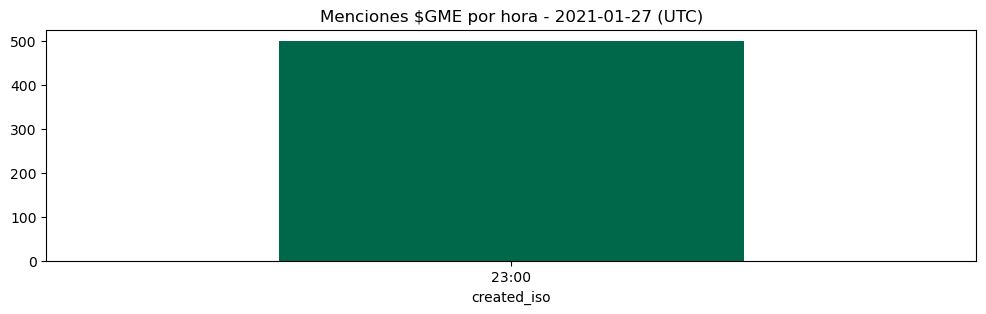

In [16]:
# Distribucion por hora (la ventana es 1 dia): sanity check de cobertura intradiaria
ax = (pd.to_datetime(df["created_iso"]).dt.floor("h").value_counts().sort_index()
      .plot(kind="bar", figsize=(12, 3), color="#00684A",
            title=f"Menciones ${TICKER} por hora - {SINCE:%Y-%m-%d} (UTC)"))
ax.set_xticklabels([l.get_text()[11:16] for l in ax.get_xticklabels()], rotation=0);

## 4. Guardar salidas y bitacora de costos

Crudo en JSONL, normalizado en Parquet (esquema unificado, seccion 7 del plan) y registro en `data/bitacora_costos.csv`. En el equipo de produccion la salida va al Disco 4 (`DATA_ROOT_OTHER_PLATFORMS`).

In [17]:
import csv
import json

_raw = Path(os.getenv("DATA_ROOT_LOCAL", "data"))
out_dir = _raw if _raw.is_absolute() else MODULE_ROOT / _raw  # siempre anclado a Code/x
out_dir.mkdir(parents=True, exist_ok=True)

raw_path = out_dir / f"raw_{EVENT_WINDOW_ID}.jsonl"
with open(raw_path, "w", encoding="utf-8") as fh:
    for t in tweets:
        fh.write(json.dumps(t, ensure_ascii=False) + "\n")

parquet_path = out_dir / f"x_{EVENT_WINDOW_ID}.parquet"
df.to_parquet(parquet_path, index=False)

bitacora = out_dir / "bitacora_costos.csv"
new_file = not bitacora.exists()
with open(bitacora, "a", newline="", encoding="utf-8") as fh:
    w = csv.writer(fh)
    if new_file:
        w.writerow(["fecha_utc", "event_window_id", "query", "paginas", "tweets",
                    "costo_est_usd", "proveedor"])
    w.writerow([stats["collected_at_utc"], EVENT_WINDOW_ID, stats["query"],
                stats["pages"], stats["tweets"], stats["est_cost_usd"], "twitterapi.io"])

print(f"Guardado: {raw_path.name} y {parquet_path.name}; bitacora actualizada")

Guardado: raw_GME_2021-01-27_2021-01-28.jsonl y x_GME_2021-01-27_2021-01-28.parquet; bitacora actualizada


## 5. Extrapolacion de costo (decision de la seccion 12)

Si el tope se alcanzo (`has_next_page` seguia en True), el volumen real del dia es mayor al recolectado; para medirlo sin descargar todo, subir el tope gradualmente o muestrear horas. Con el volumen por dia estimado: `costo_ventana = dias_ventana x tweets_por_dia x USD_PER_TWEET`.

**Checklist antes de aprobar Fase 1:**

- [ ] Fechas devueltas caen en enero 2021 (profundidad historica OK)
- [ ] Cashtag filtra correctamente (>90% de tweets con $GME)
- [ ] Repetir con una ventana de 2020 (ej. agosto 2020) para validar profundidad a inicio de la ventana de estudio
- [ ] Cruzar el conteo de una hora especifica contra SocialData.tools (validacion de cobertura entre proveedores)
- [ ] Registrar tarifa academica si fue aprobada (ajustar USD_PER_TWEET en x_client.py)
- [ ] Con cifras reales, aprobar presupuesto y alcance con el director

## 6. Validación de profundidad 2020 (inicio de la ventana de estudio)

Segunda prueba con una ventana de bajo volumen: $GME del 3 al 6 de agosto de 2020 (antes de la manía, cuando GameStop era una acción poco comentada). Objetivo: confirmar que la cobertura histórica llega al inicio de la ventana de estudio (2020), no solo a los eventos famosos de 2021.

Tope de 200 tweets (~USD 0.03). Si la ventana es de bajo volumen, quiza regrese menos que el tope; eso tambien es informacion util (volumen de linea base).

In [18]:
SINCE_2020 = datetime(2020, 8, 3)   # UTC
UNTIL_2020 = datetime(2020, 8, 6)   # UTC, exclusivo (3 dias)

query_2020 = build_query(TICKER, SINCE_2020, UNTIL_2020)
print("Query:", query_2020)

tweets_2020, stats_2020 = collect(API_KEY, query_2020, max_tweets=200)
print(stats_2020)

Query: $GME since_time:1596412800 until_time:1596672000
{'pages': 4, 'tweets': 58, 'est_cost_usd': 0.0087, 'query': '$GME since_time:1596412800 until_time:1596672000', 'collected_at_utc': '2026-07-05T05:57:15+00:00'}


In [20]:
EW_2020 = f"{TICKER}_{SINCE_2020:%Y-%m-%d}_{UNTIL_2020:%Y-%m-%d}"
df_2020 = pd.DataFrame([normalize_tweet(t, EW_2020) for t in tweets_2020]).drop_duplicates(subset="id")

if df_2020.empty:
    print("0 tweets. O la ventana no tiene menciones (posible en 2020) o la cobertura")
    print("no llega a 2020: probar otra ventana de 2020 con mas volumen antes de concluir,")
    print("por ejemplo la semana del split de Tesla (31 ago 2020) con $TSLA.")
else:
    print(f"Tweets unicos: {len(df_2020)}")
    print(f"Rango real: {df_2020['created_iso'].min()}  a  {df_2020['created_iso'].max()}")
    print(f"VALIDACION: las fechas deben ser de agosto 2020.")
    print(f"Con cashtag {TICKER}: {df_2020['cashtags'].apply(lambda c: TICKER in list(c)).mean():.1%}")
    print(f"Volumen de linea base: ~{len(df_2020)/3:.0f} menciones/dia (si no se alcanzo el tope)")

    # guardar y registrar en bitacora
    import csv, json as _json
    df_2020.to_parquet(out_dir / f"x_{EW_2020}.parquet", index=False)
    with open(out_dir / f"raw_{EW_2020}.jsonl", "w", encoding="utf-8") as fh:
        for t in tweets_2020:
            fh.write(_json.dumps(t, ensure_ascii=False) + "\n")
    with open(out_dir / "bitacora_costos.csv", "a", newline="", encoding="utf-8") as fh:
        csv.writer(fh).writerow([stats_2020["collected_at_utc"], EW_2020, stats_2020["query"],
                                 stats_2020["pages"], stats_2020["tweets"],
                                 stats_2020["est_cost_usd"], "twitterapi.io"])
    print("Guardado en data/ y registrado en la bitacora.")

Tweets unicos: 58
Rango real: 2020-08-03T15:52:10+00:00  a  2020-08-05T19:52:28+00:00
VALIDACION: las fechas deben ser de agosto 2020.
Con cashtag GME: 100.0%
Volumen de linea base: ~19 menciones/dia (si no se alcanzo el tope)
Guardado en data/ y registrado en la bitacora.


**Interpretación:** si las fechas caen en agosto 2020, la cobertura full-archive queda validada en ambos extremos de la ventana de estudio (2020 y 2021) y el proveedor pasa el piloto tecnico completo. Quedaria pendiente solo la validacion cruzada de conteos contra SocialData.tools (checklist, seccion 5) y la respuesta del precio academico antes de aprobar la Fase 1 con el director.